# Avance 1 — Análisis exploratorio de datos

**Bioactive AI** · Equipo 7 · Maestría en Inteligencia Artificial Aplicada (TC5035.10)

Etapa 1 del proyecto: predecir a partir del SMILES si un compuesto cruza la barrera hematoencefálica.

Este notebook explora **B3DB**, el conjunto elegido para esta etapa. El fundamento de esa decisión está en [`docs/referencias/02-datasets-bbb.md`](../docs/referencias/02-datasets-bbb.md) y el marco teórico en [`docs/planteamiento/marco-teorico.md`](../docs/planteamiento/marco-teorico.md).

## Preguntas que responde

1. ¿Los datos están completos y son parseables?
2. ¿Cómo se distribuyen las clases y los grupos de confiabilidad? ¿Se justifica entrenar solo con A+B?
3. ¿Los descriptores fisicoquímicos clásicos separan las clases **en estos datos**, o solo en la literatura?
4. ¿Qué tan diversa es la estructura? ¿Alcanza para un scaffold split?
5. ¿El conjunto de validación externa es utilizable?

> **Advertencia metodológica.** No se usan cifras de desempeño de la literatura como referencia. Los baselines publicados para el mismo conjunto varían entre 0.681 y 0.7194 según quién los reporte, por implementaciones distintas del scaffold split. Todo número aquí se calcula sobre los datos descargados.

## 1. Preparación

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.metrics import roc_auc_score, roc_curve

RDLogger.DisableLog("rdApp.*")          # el parseo se audita explícitamente más abajo
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
EXT = RAIZ / "data" / "external"
print("RDKit", Chem.rdBase.rdkitVersion, "| descriptores 2D disponibles:", len(Descriptors._descList))

RDKit 2026.03.6 | descriptores 2D disponibles: 217


## 2. Carga y auditoría de integridad

In [2]:
b3db = pd.read_csv(EXT / "b3db" / "B3DB_classification.tsv", sep="\t")
ext  = pd.read_csv(EXT / "b3db" / "B3DB_classification_external.tsv", sep="\t")
reg  = pd.read_csv(EXT / "b3db" / "B3DB_regression.tsv", sep="\t")

print(f"principal : {len(b3db):>5} filas")
print(f"external  : {len(ext):>5} filas   (agregados en agosto 2025)")
print(f"regression: {len(reg):>5} filas   (subconjunto con logBB numérico)")
print(f"\nprincipal + external = {len(b3db) + len(ext)}")
b3db.head(3)

principal :  7807 filas
external  :   175 filas   (agregados en agosto 2025)
regression:  1058 filas   (subconjunto con logBB numérico)

principal + external = 7982


,NO.,compound_name,IUPAC_name,SMILES,CID,logBB,BBB+/BBB-,Inchi,threshold,reference,group,comments
0,1,sulphasalazine,2-hydroxy-5-[[4-(pyridin-2-ylsulfamoyl)phenyl]...,O=C(O)c1cc(N=Nc2ccc(S(=O)(=O)Nc3ccccn3)cc2)ccc1O,5339.0,-2.69,BBB-,InChI=1S/C18H14N4O5S/c23-16-9-6-13(11-15(16)18...,NaN,R2|R2|R25|R46|,A,NaN
1,2,moxalactam,7-[[2-carboxy-2-(4-hydroxyphenyl)acetyl]amino]...,COC1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C(=O)...,3889.0,-2.52,BBB-,InChI=1S/C20H20N6O9S/c1-25-19(22-23-24-25)36-8...,NaN,R25|,A,NaN
2,3,clioquinol,5-chloro-7-iodoquinolin-8-ol,Oc1c(I)cc(Cl)c2cccnc12,2788.0,-2.40,BBB-,InChI=1S/C9H5ClINO/c10-6-4-7(11)9(13)8-5(6)2-1...,NaN,R18|R26|R27|,A,NaN


### 2.1 El conteo de 7,807 contra 7,982

El README de B3DB reporta 7,982 compuestos y el archivo principal tiene 7,807. No es una discrepancia de versión: los 175 agregados en agosto de 2025 viven en un archivo aparte que no se fusionó. Pero **no se pueden concatenar a ciegas**.

In [3]:
solapan = set(b3db["Inchi"].dropna()) & set(ext["Inchi"].dropna())
print(f"compuestos presentes en AMBOS archivos (InChI exacto): {len(solapan)}")
print(f"si se concatenan sin deduplicar: {len(b3db)+len(ext)} filas, de las cuales {len(solapan)} son duplicados")
print(f"\ncomposición del archivo externo:")
print(ext["BBB+/BBB-"].value_counts().to_string())

compuestos presentes en AMBOS archivos (InChI exacto): 11
si se concatenan sin deduplicar: 7982 filas, de las cuales 11 son duplicados

composición del archivo externo:
BBB+/BBB-
BBB+    171
BBB-      4


### 2.2 Validez de los SMILES

In [4]:
def a_mol(s):
    try:
        return Chem.MolFromSmiles(s)
    except Exception:
        return None

b3db["mol"] = b3db["SMILES"].map(a_mol)
malos = b3db[b3db["mol"].isna()]

print(f"SMILES faltantes : {b3db['SMILES'].isna().sum()}")
print(f"SMILES que NO parsean en RDKit: {len(malos)} de {len(b3db)}\n")
for _, r in malos.iterrows():
    print(f"  fila {r.name} · NO.={r['NO.']} · grupo {r['group']} · {r['BBB+/BBB-']}")
    print(f"    nombre: {r['compound_name']}")
    print(f"    SMILES: {r['SMILES']}")

SMILES faltantes : 0
SMILES que NO parsean en RDKit: 2 de 7807

  fila 5043 · NO.=5044 · grupo C · BBB-
    nombre: mepenzolatebromide
    SMILES: C[N+]1(C)CCC[C@H](OC(=O)[C+](O)(c2ccccc2)c2ccccc2)C1
  fila 7737 · NO.=7738 · grupo C · BBB-
    nombre: tiotidine
    SMILES: C[N+]1(C)CCCC(OC(=O)[C+](O)(c2ccccc2)c2ccccc2)C1


El error es de valencia: `[C+]` con cuatro enlaces explícitos no es un catión válido. Sustituirlo por un carbono neutro produce C21H26NO3+, el catión correcto del mepenzolato.

**Hay un problema de fondo peor.** Las dos filas cargan *la misma estructura*, pero una se llama `mepenzolatebromide` y la otra `tiotidine`, que son fármacos sin relación — la tiotidina es un antagonista H2. Es una inconsistencia nombre/estructura en B3DB, no solo un SMILES mal escrito, y conviene reportarla aguas arriba.

Dato tranquilizador: **ambas están en el grupo C**, el de menor confiabilidad. Es la primera evidencia de que la columna `group` funciona como filtro de calidad.

In [5]:
# ¿los otros archivos tienen el mismo problema?
for nombre, df in [("external", ext), ("regression", reg)]:
    n = sum(a_mol(s) is None for s in df["SMILES"])
    print(f"{nombre:>10}: {n} SMILES inválidos de {len(df)}")

# se descartan las 2 filas para el resto del análisis
b3db = b3db.dropna(subset=["mol"]).reset_index(drop=True)
print(f"\nconjunto de trabajo: {len(b3db)} compuestos")

  external: 0 SMILES inválidos de 175
regression: 0 SMILES inválidos de 1058

conjunto de trabajo: 7805 compuestos


### 2.3 Duplicados por estructura

La columna `Inchi` viene del archivo. Aquí se recalcula el InChIKey desde el SMILES con RDKit, que es la forma correcta de deduplicar: detecta compuestos idénticos escritos con SMILES distintos.

In [6]:
b3db["inchikey"] = [Chem.MolToInchiKey(m) for m in b3db["mol"]]
b3db["esqueleto"] = b3db["inchikey"].str[:14]   # primeros 14 = conectividad, ignora estéreo e isótopos

dup_exacto = b3db["inchikey"].duplicated().sum()
dup_esq    = b3db["esqueleto"].duplicated().sum()
print(f"duplicados por InChIKey completo (estéreo incluido): {dup_exacto}")
print(f"duplicados por esqueleto (ignorando estereoquímica): {dup_esq}")

# ¿hay duplicados con etiquetas EN CONFLICTO? Esto es lo que de verdad importa.
conf = (b3db.groupby("inchikey")["BBB+/BBB-"].nunique() > 1)
claves_conf = conf[conf].index
print(f"\ncompuestos duplicados con etiquetas CONTRADICTORIAS: {len(claves_conf)}")
if len(claves_conf):
    print(b3db[b3db["inchikey"].isin(claves_conf)]
          [["compound_name","BBB+/BBB-","group","inchikey"]]
          .sort_values("inchikey").to_string(index=False))

duplicados por InChIKey completo (estéreo incluido): 0
duplicados por esqueleto (ignorando estereoquímica): 3783

compuestos duplicados con etiquetas CONTRADICTORIAS: 0


El InChIKey completo no muestra duplicados, pero el esqueleto sí, y muchos. Vale la pena medir qué significa eso para el tamaño real de la muestra.

In [7]:
g = b3db.groupby("esqueleto")["BBB+/BBB-"].agg(["nunique","size"])
conf_esq = g[g["nunique"] > 1]

print(f"filas en el conjunto            : {len(b3db)}")
print(f"esqueletos de conectividad únicos: {b3db['esqueleto'].nunique()}")
print(f"\n>> el tamaño EFECTIVO de muestra es {b3db['esqueleto'].nunique()}, no {len(b3db)}")
print(f"\nesqueletos con etiquetas CONTRADICTORIAS entre sus estereoisómeros: {len(conf_esq)}")
print(f"compuestos afectados: {conf_esq['size'].sum()} ({conf_esq['size'].sum()/len(b3db)*100:.1f}%)")
print(f"\ndistribución de multiplicidad por esqueleto:")
print(g["size"].value_counts().sort_index().head(8).to_string())

print("\nejemplos de esqueletos muy repetidos:")
for esq in g.sort_values("size", ascending=False).head(3).index:
    sub = b3db[b3db["esqueleto"] == esq]
    nombres = [str(x) for x in sub["compound_name"].head(4) if str(x) != "nan"]
    print(f"  {esq}  n={len(sub)}  clases={dict(sub['BBB+/BBB-'].value_counts())}")
    print(f"    {', '.join(nombres)}")

filas en el conjunto            : 7805
esqueletos de conectividad únicos: 4022

>> el tamaño EFECTIVO de muestra es 4022, no 7805

esqueletos con etiquetas CONTRADICTORIAS entre sus estereoisómeros: 130
compuestos afectados: 426 (5.5%)

distribución de multiplicidad por esqueleto:
size
1    2534
2     442
3     454
4     190
5     217
6     127
7      48
8       8

ejemplos de esqueletos muy repetidos:
  IECPWNUMDGFDKC  n=9  clases={'BBB-': np.int64(8), 'BBB+': np.int64(1)}
    fusidic acid, mfcd00865135
  KMIPKYQIOVAHOP  n=9  clases={'BBB-': np.int64(9)}
    (6r)-7-[[(2z)-2-(2-amino-1,3-thiazol-4-yl)-2-methoxyiminoacetyl]amino]-3-[(z)-2-(4-methyl-1,3-thiazol-5-yl)ethenyl]-8-oxo-5-thia-1-azabicyclo[4.2.0]oct-2-ene-2-carboxylic acid, cefditoren
  NNULBSISHYWZJU  n=8  clases={'BBB-': np.int64(7), 'BBB+': np.int64(1)}
    ceftizoxime, (6s)-7-[[(2e)-2-(2-amino-1,3-thiazol-4-yl)-2-methoxyiminoacetyl]amino]-8-oxo-5-thia-1-azabicyclo[4.2.0]oct-2-ene-2-carboxylic acid, schembl3731467, ceftizox

Esto matiza el titular de "7,807 compuestos". Entradas como la morfina aparecen ocho veces —como estereoisómeros o duplicados de nombre distinto—, y la codeína conviven con la isocodeína y con su nombre sistemático. **La información independiente es cercana a la mitad de lo que sugiere el conteo de filas.**

Dos consecuencias prácticas:

1. **El scaffold split es aún más necesario.** Un split aleatorio pondría estereoisómeros del mismo compuesto en entrenamiento y prueba, lo que infla el desempeño sin que el modelo generalice a química nueva.
2. **Los esqueletos con etiquetas contradictorias entre estereoisómeros** son candidatos a acantilados de actividad genuinos o a inconsistencias de etiquetado. Conviene revisarlos antes de entrenar, no después.

## 3. Distribución de clases y de confiabilidad

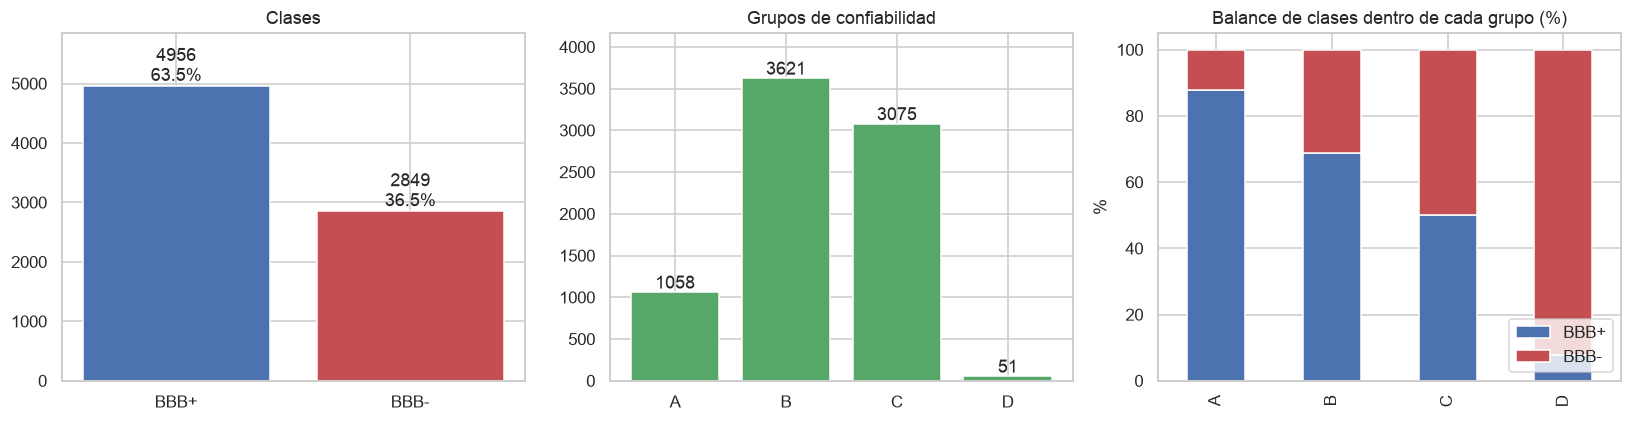

razón de desbalance BBB+/BBB-: 1.74 a 1

conteos por grupo y clase:
BBB+/BBB-  BBB+  BBB-   All
group                      
A           930   128  1058
B          2486  1135  3621
C          1536  1539  3075
D             4    47    51
All        4956  2849  7805


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cls = b3db["BBB+/BBB-"].value_counts()
axes[0].bar(cls.index, cls.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(cls.values):
    axes[0].text(i, v, f"{v}\n{v/len(b3db)*100:.1f}%", ha="center", va="bottom")
axes[0].set_title("Clases")
axes[0].set_ylim(0, cls.max()*1.18)

grp = b3db["group"].value_counts().sort_index()
axes[1].bar(grp.index, grp.values, color="#55A868")
for i, v in enumerate(grp.values):
    axes[1].text(i, v, str(v), ha="center", va="bottom")
axes[1].set_title("Grupos de confiabilidad")
axes[1].set_ylim(0, grp.max()*1.15)

ct = pd.crosstab(b3db["group"], b3db["BBB+/BBB-"], normalize="index")*100
ct.plot(kind="bar", stacked=True, ax=axes[2], color=["#4C72B0", "#C44E52"], legend=True)
axes[2].set_title("Balance de clases dentro de cada grupo (%)")
axes[2].set_xlabel(""); axes[2].set_ylabel("%")
axes[2].legend(title="", loc="lower right")

plt.tight_layout(); plt.show()

print("razón de desbalance BBB+/BBB-: {:.2f} a 1".format(cls.max()/cls.min()))
print("\nconteos por grupo y clase:")
print(pd.crosstab(b3db["group"], b3db["BBB+/BBB-"], margins=True).to_string())

### 3.1 ¿Se justifica entrenar solo con A+B?

Los grupos codifican el grado de acuerdo entre las fuentes originales:

| Grupo | Significado |
|---|---|
| **A** | Tienen logBB numérico medido |
| **B** | Las fuentes declararon el umbral −1 y coincidieron |
| **C** | Coinciden en la etiqueta, pero ninguna declaró el umbral |
| **D** | Etiquetas contradictorias entre fuentes |

El grupo C es el más grande después de B, así que excluirlo cuesta datos. La pregunta es si su ruido lo compensa.

In [9]:
print("declaración de umbral por grupo (columna 'threshold'):")
print(pd.crosstab(b3db["group"], b3db["threshold"].fillna("(vacío)")).to_string())

ab = b3db[b3db["group"].isin(["A","B"])]
c  = b3db[b3db["group"] == "C"]
print(f"\nA+B : {len(ab):>5} compuestos · {(ab['BBB+/BBB-']=='BBB+').mean()*100:.1f}% BBB+")
print(f"C   : {len(c):>5} compuestos · {(c['BBB+/BBB-']=='BBB+').mean()*100:.1f}% BBB+")
print(f"D   : {(b3db['group']=='D').sum():>5} compuestos")
print(f"\ncosto de excluir C: se pierde el {len(c)/len(b3db)*100:.1f}% de los datos")

declaración de umbral por grupo (columna 'threshold'):
threshold  -1.0   (vacío)
group                    
A             0      1058
B          3621         0
C             0      3075
D             0        51

A+B :  4679 compuestos · 73.0% BBB+
C   :  3075 compuestos · 50.0% BBB+
D   :    51 compuestos

costo de excluir C: se pierde el 39.4% de los datos


Nota que el balance de clases **difiere entre A+B y C**. Si esa diferencia es grande, mezclarlos introduce un desplazamiento de distribución, no solo ruido de etiqueta — un argumento adicional para tratarlos por separado en vez de agrupar todo.

## 4. Descriptores fisicoquímicos

In [10]:
def descriptores(m):
    return {
        "TPSA":  Descriptors.TPSA(m),
        "logP":  Descriptors.MolLogP(m),
        "MW":    Descriptors.MolWt(m),
        "HBD":   rdMolDescriptors.CalcNumHBD(m),
        "HBA":   rdMolDescriptors.CalcNumHBA(m),
        "RotB":  rdMolDescriptors.CalcNumRotatableBonds(m),
        "Arom":  rdMolDescriptors.CalcNumAromaticRings(m),
        "Fsp3":  rdMolDescriptors.CalcFractionCSP3(m),
        "HeavyAtoms": m.GetNumHeavyAtoms(),
    }

desc = pd.DataFrame([descriptores(m) for m in b3db["mol"]], index=b3db.index)
b3db = pd.concat([b3db, desc], axis=1)
b3db["y"] = (b3db["BBB+/BBB-"] == "BBB+").astype(int)   # 1 = cruza

b3db[list(desc.columns) + ["y"]].groupby("y").describe().T.round(2).loc[
    [(c, s) for c in ["TPSA","logP","MW","HBD","HBA"] for s in ["mean","50%","std"]]
]

y               0       1
TPSA mean  133.92   60.04
     50%   115.06   54.03
     std    81.49   37.51
logP mean    1.45    2.87
     50%     1.46    2.92
     std     2.76    1.58
MW   mean  464.72  339.90
     50%   424.53  330.48
     std   211.18  121.13
HBD  mean    3.37    1.23
     50%     3.00    1.00
     std     3.01    1.09
HBA  mean    7.61    3.98
     50%     6.00    4.00
     std     4.47    2.21

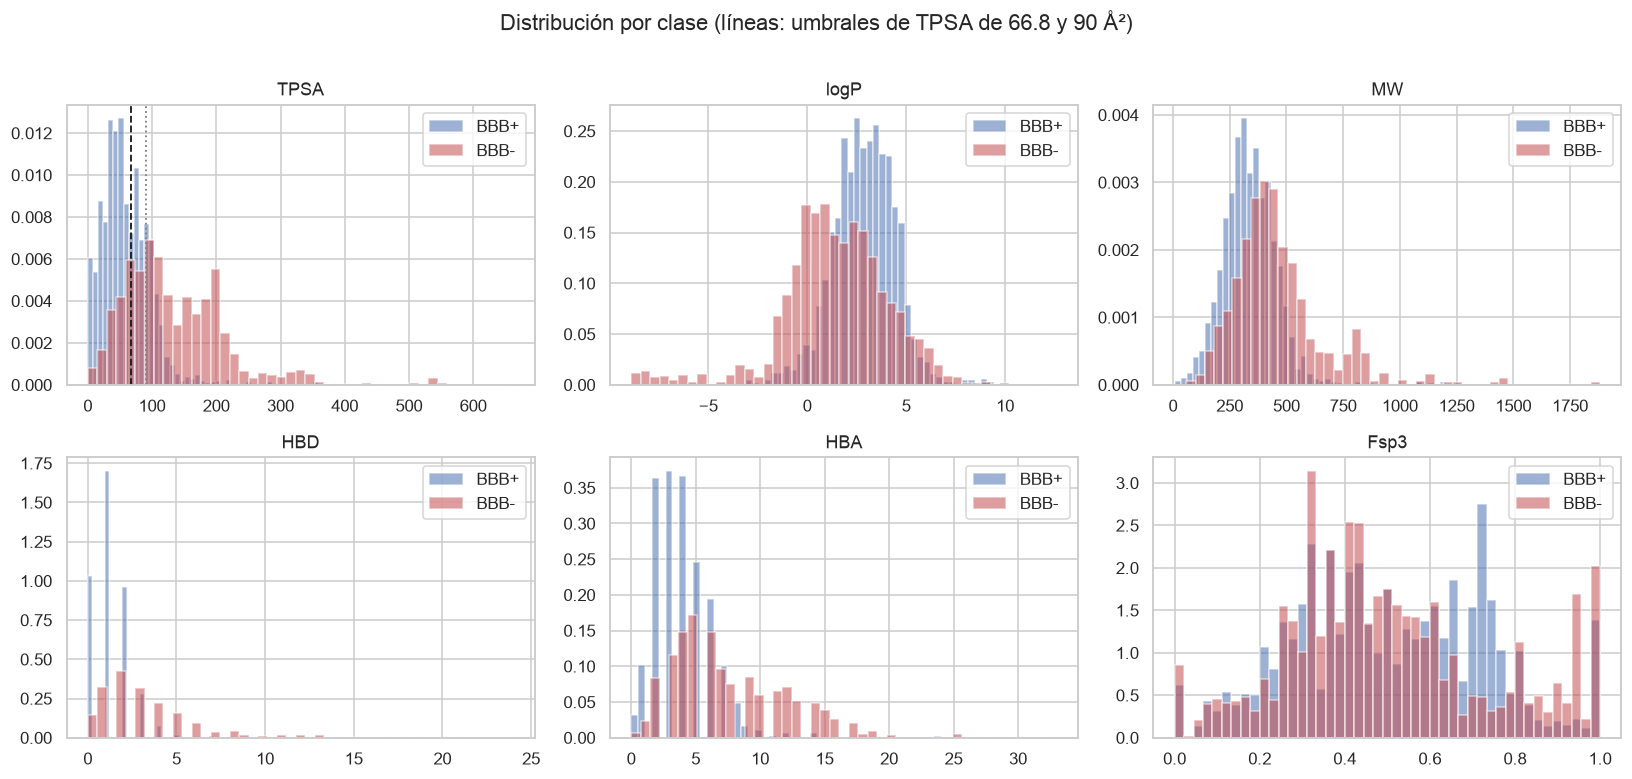

In [11]:
principales = ["TPSA","logP","MW","HBD","HBA","Fsp3"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), principales):
    for etiqueta, color in [("BBB+","#4C72B0"), ("BBB-","#C44E52")]:
        sub = b3db.loc[b3db["BBB+/BBB-"]==etiqueta, col]
        ax.hist(sub, bins=45, alpha=.55, label=etiqueta, color=color, density=True)
    ax.set_title(col); ax.legend()
axes[0,0].axvline(66.8, ls="--", c="k", lw=1.2)
axes[0,0].axvline(90,   ls=":",  c="gray", lw=1.2)
axes[0,0].text(68, ax.get_ylim()[1]*.02, "", fontsize=8)
plt.suptitle("Distribución por clase (líneas: umbrales de TPSA de 66.8 y 90 Å²)", y=1.01)
plt.tight_layout(); plt.show()

### 4.1 Poder discriminante individual, medido en estos datos

La literatura reporta, sobre el subconjunto de 1,058 compuestos con logBB, que TPSA es el mejor predictor individual con AUC 0.746, seguido de HBD (0.699), HBA (0.673), logP (0.617) y peso molecular (0.583).

Aquí se recalcula sobre **los dos conjuntos** para comparar de forma honesta: el subconjunto comparable (grupo A, que es el que tiene logBB) y el conjunto completo.

In [12]:
def aucs(df, etiqueta):
    filas = []
    for col in ["TPSA","logP","MW","HBD","HBA","Fsp3","RotB","Arom","HeavyAtoms"]:
        a = roc_auc_score(df["y"], df[col])
        # un descriptor puede discriminar en sentido inverso; se reporta el poder, no la dirección
        filas.append({"descriptor": col, "AUC": max(a, 1-a), "sentido": "+" if a>=.5 else "−"})
    return (pd.DataFrame(filas).assign(conjunto=etiqueta)
            .sort_values("AUC", ascending=False))

comp = pd.concat([
    aucs(b3db[b3db["group"]=="A"], f"grupo A (n={(b3db['group']=='A').sum()})"),
    aucs(b3db[b3db["group"].isin(["A","B"])], f"A+B (n={b3db['group'].isin(['A','B']).sum()})"),
    aucs(b3db, f"completo (n={len(b3db)})"),
])
tabla = comp.pivot(index="descriptor", columns="conjunto", values="AUC").round(3)
tabla["publicado (n=1058)"] = pd.Series({"TPSA":0.746,"HBD":0.699,"HBA":0.673,"logP":0.617,"MW":0.583})
tabla.sort_values(tabla.columns[0], ascending=False)

conjunto,A+B (n=4679),completo (n=7805),grupo A (n=1058),publicado (n=1058)
descriptor,,,,
TPSA,0.850,0.814,0.797,0.746
HBD,0.811,0.777,0.748,0.699
HBA,0.803,0.764,0.728,0.673
MW,0.729,0.703,0.612,0.583
logP,0.728,0.682,0.620,0.617
HeavyAtoms,0.710,0.683,0.599,NaN
RotB,0.684,0.695,0.627,NaN
Arom,0.501,0.525,0.582,NaN
Fsp3,0.501,0.516,0.526,NaN


### 4.2 El umbral óptimo de TPSA

La literatura sitúa el óptimo en 66.8 Å², notablemente más estricto que el clásico de ~90. Aquí se rederiva con el estadístico J de Youden.

In [13]:
def umbral_optimo(df, col="TPSA"):
    # TPSA alto predice BBB-, así que se invierte el signo para la curva ROC
    fpr, tpr, thr = roc_curve(df["y"], -df[col])
    j = tpr - fpr
    return -thr[j.argmax()], roc_auc_score(df["y"], -df[col]), j.max()

for etiqueta, sub in [("grupo A", b3db[b3db["group"]=="A"]),
                      ("A+B",     b3db[b3db["group"].isin(["A","B"])]),
                      ("completo", b3db)]:
    t, a, j = umbral_optimo(sub)
    print(f"{etiqueta:>9} (n={len(sub):>5}) · TPSA óptimo = {t:6.1f} Å² · AUC = {a:.3f} · J = {j:.3f}")
print("\npublicado sobre n=1058: TPSA óptimo = 66.8 Å², AUC = 0.746")

  grupo A (n= 1058) · TPSA óptimo =   66.6 Å² · AUC = 0.797 · J = 0.500
      A+B (n= 4679) · TPSA óptimo =   83.6 Å² · AUC = 0.850 · J = 0.547
 completo (n= 7805) · TPSA óptimo =  101.9 Å² · AUC = 0.814 · J = 0.485

publicado sobre n=1058: TPSA óptimo = 66.8 Å², AUC = 0.746


### 4.3 La regla de dos parámetros: TPSA < 67 Å² y HBD ≤ 1

La literatura reporta 96.6% de precisión para BBB+ y especificidad de 0.852 sobre el subconjunto con logBB. Se evalúa aquí, junto con las reglas compuestas clásicas para comparar.

In [14]:
def evaluar(df, mascara, nombre):
    pred = mascara.astype(int)
    tp = ((pred==1) & (df["y"]==1)).sum(); fp = ((pred==1) & (df["y"]==0)).sum()
    tn = ((pred==0) & (df["y"]==0)).sum(); fn = ((pred==0) & (df["y"]==1)).sum()
    prec = tp/(tp+fp) if tp+fp else np.nan
    return {"regla": nombre, "precisión BBB+": prec, "sensibilidad": tp/(tp+fn),
            "especificidad": tn/(tn+fp), "cobertura": (tp+fp)/len(df),
            "AUC": roc_auc_score(df["y"], pred)}

def tabla_reglas(df, etiqueta):
    r = [
        evaluar(df, (df.TPSA < 67) & (df.HBD <= 1), "TPSA<67 y HBD≤1"),
        evaluar(df, df.TPSA < 90,                   "TPSA<90 (clásica)"),
        evaluar(df, df.TPSA < 67,                   "TPSA<67 sola"),
        evaluar(df, (df.MW<=500)&(df.logP<=5)&(df.HBD<=5)&(df.HBA<=10), "Lipinski (regla de 5)"),
        evaluar(df, (df.TPSA<=140)&(df.RotB<=10),   "Veber"),
    ]
    return pd.DataFrame(r).assign(conjunto=etiqueta).round(3)

pd.concat([tabla_reglas(b3db[b3db["group"]=="A"], "grupo A"),
           tabla_reglas(b3db, "completo")]).set_index(["conjunto","regla"])

precisión BBB+  sensibilidad  especificidad  \
conjunto regla                                                                
grupo A  TPSA<67 y HBD≤1                 0.966         0.589          0.852   
         TPSA<90 (clásica)               0.923         0.882          0.469   
         TPSA<67 sola                    0.953         0.718          0.742   
         Lipinski (regla de 5)           0.890         0.857          0.227   
         Veber                           0.894         0.944          0.188   
completo TPSA<67 y HBD≤1                 0.853         0.515          0.846   
         TPSA<90 (clásica)               0.806         0.790          0.670   
         TPSA<67 sola                    0.838         0.610          0.794   
         Lipinski (regla de 5)           0.728         0.885          0.424   
         Veber                           0.747         0.966          0.431   

                                cobertura    AUC  
conjunto regla                                    
grupo A  TPSA<67 y HBD≤1            0.536  0.720  
         TPSA<90 (clásica)          0.839  0.675  
         TPSA<67 sola               0.663  0.730  
         Lipinski (regla de 5)      0.847  0.542  
         Veber                      0.928  0.566  
completo TPSA<67 y HBD≤1            0.383  0.680  
         TPSA<90 (clásica)          0.622  0.730  
         TPSA<67 sola               0.462  0.702  
         Lipinski (regla de 5)      0.772  0.655  
         Veber                      0.821  0.698

> **Cómo leer esta tabla.** La precisión alta de una regla permisiva puede ser un artefacto del desbalance: si el 63.5% de los compuestos son BBB+, una regla que marque casi todo como positivo tendrá precisión cercana a 0.635 sin aportar nada. Por eso hay que leer precisión, especificidad y cobertura juntas, y por eso el AUPRC es más diagnóstico que el AUROC en conjuntos desbalanceados (capítulo 4.7 del marco teórico).

## 5. Diversidad estructural y viabilidad del scaffold split

In [15]:
def andamio(m):
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=m)
    except Exception:
        return None

b3db["andamio"] = [andamio(m) for m in b3db["mol"]]
sin_andamio = b3db["andamio"].isna().sum() + (b3db["andamio"]=="").sum()

conteo = b3db.loc[b3db["andamio"].notna() & (b3db["andamio"]!=""), "andamio"].value_counts()
print(f"compuestos sin andamio (acíclicos): {sin_andamio}")
print(f"andamios de Murcko distintos: {len(conteo)}")
print(f"andamios únicos (aparecen 1 vez): {(conteo==1).sum()}  ({(conteo==1).sum()/len(conteo)*100:.1f}%)")
print(f"compuestos en andamios únicos: {(conteo==1).sum()} ({(conteo==1).sum()/len(b3db)*100:.1f}% del total)")
print(f"\nrazón compuestos/andamio: {len(b3db)/len(conteo):.2f}")

acum = conteo.cumsum()/len(b3db)*100
for n in [10, 32, 100, 500]:
    if n <= len(conteo):
        print(f"los {n:>3} andamios más frecuentes cubren el {acum.iloc[n-1]:5.1f}% de los compuestos")

compuestos sin andamio (acíclicos): 311
andamios de Murcko distintos: 2128
andamios únicos (aparecen 1 vez): 1133  (53.2%)
compuestos en andamios únicos: 1133 (14.5% del total)

razón compuestos/andamio: 3.67
los  10 andamios más frecuentes cubren el  17.2% de los compuestos
los  32 andamios más frecuentes cubren el  26.6% de los compuestos
los 100 andamios más frecuentes cubren el  38.9% de los compuestos
los 500 andamios más frecuentes cubren el  66.5% de los compuestos


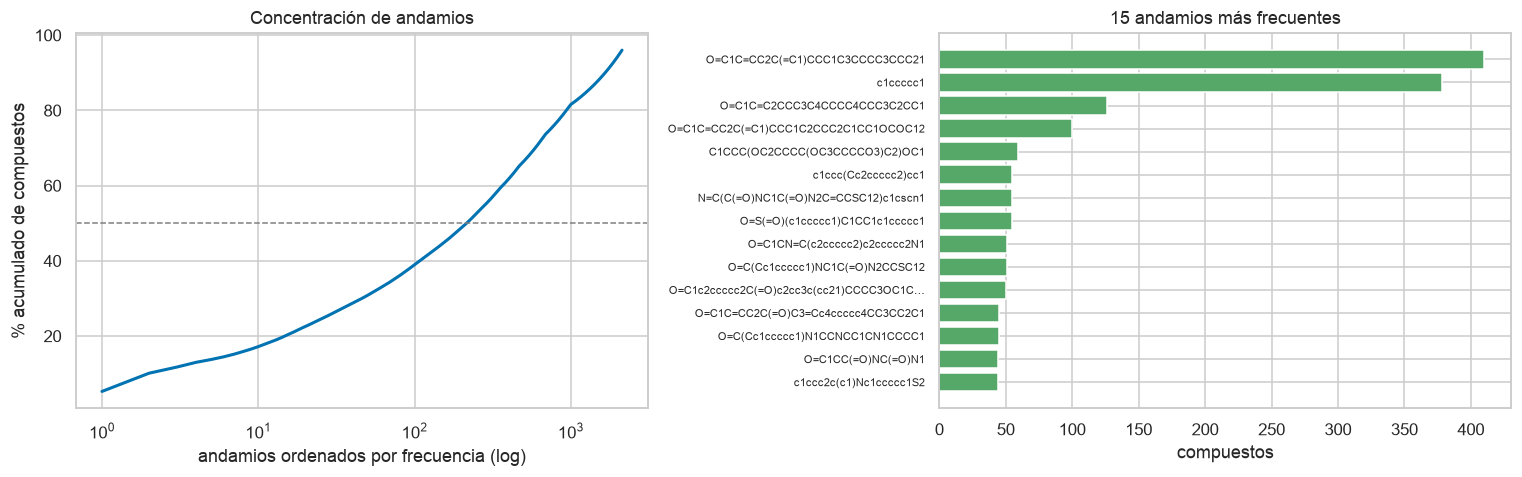

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(range(1, len(conteo)+1), acum.values, lw=2)
axes[0].axhline(50, ls="--", c="gray", lw=1)
axes[0].set_xscale("log")
axes[0].set_xlabel("andamios ordenados por frecuencia (log)")
axes[0].set_ylabel("% acumulado de compuestos")
axes[0].set_title("Concentración de andamios")

top = conteo.head(15)
axes[1].barh(range(len(top)), top.values, color="#55A868")
axes[1].set_yticks(range(len(top)))
axes[1].set_yticklabels([s[:38] + ("…" if len(s)>38 else "") for s in top.index], fontsize=7)
axes[1].invert_yaxis()
axes[1].set_title("15 andamios más frecuentes")
axes[1].set_xlabel("compuestos")

plt.tight_layout(); plt.show()

### 5.1 Lectura para el scaffold split

Un scaffold split agrupa por andamio y reparte grupos completos entre entrenamiento y prueba, de modo que ninguna estructura del entrenamiento reaparezca en la prueba. Dos condiciones lo hacen viable:

- **Muchos andamios distintos**, para que los grupos sean pequeños y el reparto quede balanceado.
- **Ningún andamio dominante**, porque uno que concentre buena parte del conjunto forzaría un split desbalanceado.

Una proporción alta de andamios que aparecen una sola vez es buena señal: significa diversidad estructural real.

In [17]:
# ¿el balance de clases se mantiene dentro de los andamios grandes?
grandes = conteo.head(10).index
res = []
for s in grandes:
    sub = b3db[b3db["andamio"]==s]
    res.append({"andamio": s[:45], "n": len(sub), "% BBB+": (sub["y"].mean()*100).round(1)})
pd.DataFrame(res)

,andamio,n,% BBB+
0,O=C1C=CC2C(=C1)CCC1C3CCCC3CCC21,410,99.5
1,c1ccccc1,378,66.1
2,O=C1C=C2CCC3C4CCCC4CCC3C2CC1,126,78.6
3,O=C1C=CC2C(=C1)CCC1C2CCC2C1CC1OCOC12,100,99.0
4,C1CCC(OC2CCCC(OC3CCCCO3)C2)OC1,59,0.0
5,c1ccc(Cc2ccccc2)cc1,55,81.8
6,N=C(C(=O)NC1C(=O)N2C=CCSC12)c1cscn1,55,5.5
7,O=S(=O)(c1ccccc1)C1CC1c1ccccc1,55,52.7
8,O=C1CN=C(c2ccccc2)c2ccccc2N1,51,100.0
9,O=C(Cc1ccccc1)NC1C(=O)N2CCSC12,51,0.0


## 6. El conjunto de validación externa

In [18]:
sv = pd.read_csv(EXT / "spielvogel2025" / "bbb_penetration_database.csv", sep=";")
print(f"Spielvogel et al. 2025: {len(sv)} compuestos · {len(sv.columns)} columnas\n")
print(sv["CNS positivity"].value_counts().to_string())
print("\n¿trae estructura?", [c for c in sv.columns if any(k in c.lower() for k in ("smi","inchi","cid"))] or "NO — solo nombres y descriptores precalculados")
print("\nprimeros nombres:", list(sv["Compound"].head(5)))

Spielvogel et al. 2025: 154 compuestos · 26 columnas

CNS positivity
positive    68
efflux      44
negative    42

¿trae estructura? NO — solo nombres y descriptores precalculados

primeros nombres: ['Sitagliptin', 'Teicoplanin', 'Fluoroethyl-Carfentanilhydrochloride', 'SCH-23388hydrochloride', 'SCH-23390hydrochloride']


**Limitación confirmada.** El conjunto no trae SMILES ni InChI: son el nombre del compuesto y 25 descriptores precalculados. Para usarlo con este pipeline hay que resolver los 154 nombres a estructura, por ejemplo vía PubChem, y revisar a mano los que no resuelvan limpiamente — entradas como `Fluoroethyl-Carfentanilhydrochloride` son propensas a fallar.

Su valor justifica el trabajo: **separa los sustratos de eflujo como clase propia** en vez de forzar una etiqueta binaria, que es exactamente la ambigüedad por concentración que señalaron los asesores.

Como los descriptores precalculados usan software distinto (ACD), se comparan con los calculados por RDKit sobre B3DB para ver si son conmensurables.

In [19]:
comunes = {"MW":" MW (g/mol)", "TPSA":"tPSA", "logP":"logP"}
print("comparación de rangos, B3DB (RDKit) contra Spielvogel (ACD/precalculado):\n")
for rd, ac in comunes.items():
    if ac in sv.columns:
        a = pd.to_numeric(sv[ac], errors="coerce").dropna()
        print(f"{rd:>5}  B3DB: media {b3db[rd].mean():7.1f}  rango [{b3db[rd].min():.1f}, {b3db[rd].max():.1f}]")
        print(f"{'':>5}  SV  : media {a.mean():7.1f}  rango [{a.min():.1f}, {a.max():.1f}]  (n={len(a)})")

comparación de rangos, B3DB (RDKit) contra Spielvogel (ACD/precalculado):

   MW  B3DB: media   385.5  rango [6.9, 1882.3]
       SV  : media   434.6  rango [142.2, 1879.7]  (n=154)
 TPSA  B3DB: media    87.0  rango [0.0, 662.4]
       SV  : media    85.3  rango [3.2, 662.0]  (n=154)
 logP  B3DB: media     2.4  rango [-8.9, 12.6]
       SV  : media     3.0  rango [-3.2, 9.1]  (n=136)


## 7. Conclusiones del Avance 1

### 7.1 Integridad de los datos

El conjunto está en buen estado, con tres salvedades que ya quedaron medidas:

- **2 SMILES de 7,807 no parsean** en RDKit, por `[C+]` con cuatro enlaces. Ambos están en el grupo C. Peor que el error de sintaxis: las dos filas cargan la *misma* estructura con nombres de fármacos distintos y sin relación (`mepenzolatebromide` y `tiotidine`). Es una inconsistencia nombre/estructura que conviene reportar aguas arriba.
- **Cero duplicados por InChIKey completo y cero etiquetas contradictorias** a ese nivel. B3DB está bien deduplicado donde dice estarlo.
- **Pero el tamaño efectivo de muestra es ~4,022 entidades, no 7,805.** Casi la mitad de las filas comparten esqueleto de conectividad con otra. La morfina aparece ocho veces. Y 130 esqueletos tienen etiquetas contradictorias entre sus estereoisómeros, afectando el 5.5% de los compuestos.

**Cuando se reporte el tamaño del conjunto en el documento, hay que dar ambas cifras.** Decir "7,807 compuestos" sin más sobreestima la información independiente por un factor cercano a dos.

### 7.2 La decisión sobre los grupos de confiabilidad

Los datos respaldan entrenar con A+B, y por una razón más fuerte de la que esperábamos:

| Subconjunto | n | % BBB+ |
|---|---|---|
| A+B | 4,679 | **73.0%** |
| C | 3,075 | **50.0%** |

No es solo que C tenga más ruido: **su distribución de clases es distinta**. Mezclarlos introduce un desplazamiento de distribución, no únicamente ruido de etiqueta. Que C quede exactamente en 50.0% llama la atención y sugiere que se curó con un criterio diferente.

El costo es real: excluir C pierde el 39.4% de los datos. La decisión es entrenar con A+B y reportar C como análisis de sensibilidad, no descartarlo en silencio.

### 7.3 Los descriptores clásicos sí discriminan, pero el umbral no es transferible

El resultado más útil de este análisis. **La regla publicada se replica de forma casi exacta en el subconjunto comparable y se degrada en el resto:**

| | Grupo A (n=1,058) | Publicado (n=1,058) | Conjunto completo |
|---|---|---|---|
| Precisión de TPSA<67 y HBD≤1 | **0.966** | 96.6% | 0.853 |
| Especificidad | **0.852** | 0.852 | 0.846 |
| TPSA óptimo | **66.6 Å²** | 66.8 Å² | 101.9 Å² |

Sobre el grupo A, la réplica es exacta hasta el tercer decimal. Eso da confianza en la implementación y en la fuente.

**Pero el umbral óptimo se mueve mucho según el subconjunto:** 66.6 Å² en el grupo A, **83.6 Å² en A+B** —el conjunto con el que realmente vamos a entrenar— y 101.9 Å² en el completo. La cifra de 66.8 Å² de la literatura no es una constante de la barrera hematoencefálica: es el óptimo del subconjunto con logBB, que está fuertemente desbalanceado hacia BBB+.

**Consecuencia para la tesis:** al citar el umbral hay que decir sobre qué subconjunto se midió. Y para verificar las explicaciones del modelo conviene usar el umbral rederivado sobre A+B, no el publicado.

Orden de poder discriminante en A+B: **TPSA (0.850) > HBD (0.811) > HBA (0.803) > MW (0.729) ≈ logP (0.728)**. Coincide con la literatura en el orden, con valores más altos. `Fsp3` y el número de anillos aromáticos no discriminan (AUC ≈ 0.50), lo cual es información útil: no vale la pena darles peso interpretativo.

Las reglas compuestas clásicas quedan claramente por debajo: Lipinski da AUC 0.542 y Veber 0.566 sobre el grupo A.

### 7.4 Desbalance

La razón es de 1.74 a 1 en el conjunto completo y sube a 2.70 a 1 en A+B. No es extremo, pero basta para que la exactitud engañe. **Se usarán MCC y AUPRC como métricas principales**, no exactitud ni AUROC solos.

### 7.5 El scaffold split es viable y necesario

- **2,128 andamios de Murcko distintos**, con el 53.2% apareciendo una sola vez.
- Los 10 andamios más frecuentes cubren solo el 17.2% de los compuestos: no hay uno dominante.
- 311 compuestos son acíclicos y no tienen andamio; hay que decidir cómo tratarlos.

Pero el dato decisivo es otro: **los andamios grandes tienen pureza de clase extrema**. El más frecuente (410 compuestos, un esqueleto esteroideo) es 99.5% BBB+; otro de 59 compuestos es 0.0% BBB+; otro de 51 es 100% BBB+.

**Eso es exactamente por qué un split aleatorio infla el desempeño.** Si un andamio con 410 compuestos casi puros se reparte entre entrenamiento y prueba, el modelo solo tiene que reconocer el andamio, no aprender química. El scaffold split lo impide por construcción.

### 7.6 El conjunto de validación externa necesita trabajo previo

154 compuestos con 68 positivos, 42 negativos y 44 sustratos de eflujo como clase propia — valioso porque no fuerza el binario.

**Pero no trae SMILES ni InChI.** Hay que resolver los 154 nombres a estructura vía PubChem y revisar a mano los que fallen. Los rangos de TPSA y peso molecular son comparables con los de B3DB, así que los descriptores precalculados con ACD parecen conmensurables con los de RDKit, aunque no idénticos.

### 7.7 Siguientes pasos

**Avance 2** (`02_Feature_Eng.ipynb`):

1. Descriptores RDKit (217) más Morgan/ECFP4 de 2048 bits con `rdFingerprintGenerator`.
2. Construir el scaffold split agrupando por andamio de Murcko, verificando que los estereoisómeros del mismo esqueleto no se separen.
3. Rederivar los umbrales de verificación sobre A+B, no usar los publicados.

**Tareas de datos pendientes:**

- Resolver los 154 nombres de Spielvogel a SMILES.
- Revisar los 130 esqueletos con etiquetas contradictorias: ¿acantilados de actividad o errores?
- Reportar a B3DB las dos filas con la inconsistencia nombre/estructura.